<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/HVAC_percentile_calc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
분석 대상 파일: Bu-an_1995_STN_DATA.csv
총 유효 데이터 개수: 247,296 개
--------------------------------------------------
HVAC 여름 외기온도 (상위 0.4%): 32.80 °C
HVAC 겨울 외기온도 (하위 0.4%): -8.80 °C


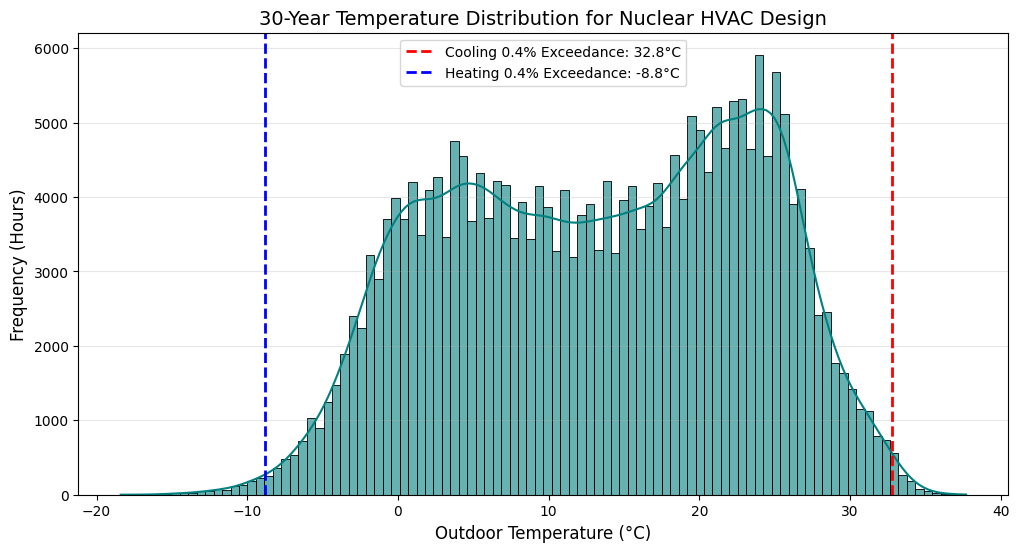

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. 구글 드라이브 마운트 (실행 시 나타나는 링크를 통해 인증이 필요합니다)
drive.mount('/content/drive')

# 2. 파일 경로 설정
file_path = '/content/drive/MyDrive/Bu-an_1995_STN_DATA.csv'

# 파일 존재 여부 확인
if not os.path.exists(file_path):
    print(f"파일을 찾을 수 없습니다: {file_path}")
    print("구글 드라이브 내의 정확한 파일 경로를 확인해 주세요.")
else:
    # 3. 데이터 로드
    df = pd.read_csv(file_path)

    # 4. 데이터 전처리 (시간별 데이터 추출 및 직렬화)
    # 01시부터 24시까지의 컬럼 리스트
    hourly_cols = [f'{i:02d}' for i in range(1, 25)]

    # 2D 데이터를 1D Series로 변환 (Stacking)
    temp_series = df[hourly_cols].stack()

    # 결측치(-99.0 및 NaN) 제거
    temp_series = temp_series[temp_series != -99.0].dropna()

    # 5. 0.4% 설계 외기온도 산출
    # 냉방(Cooling): 상위 0.4% = 99.6 백분위수
    cooling_04 = temp_series.quantile(0.996)

    # 난방(Heating): 하위 0.4% = 0.4 백분위수
    heating_04 = temp_series.quantile(0.004)

    # 6. 결과 출력
    print("=" * 50)
    print(f"분석 대상 파일: {os.path.basename(file_path)}")
    print(f"총 유효 데이터 개수: {len(temp_series):,} 개")
    print("-" * 50)
    print(f"HVAC 여름 외기온도 (상위 0.4%): {cooling_04:.2f} °C")
    print(f"HVAC 겨울 외기온도 (하위 0.4%): {heating_04:.2f} °C")
    print("=" * 50)

    # 7. 분포 시각화
    plt.figure(figsize=(12, 6))
    sns.histplot(temp_series, bins=100, kde=True, color='teal', alpha=0.6)

    # 설계 지점 수직선 표시
    plt.axvline(cooling_04, color='red', linestyle='--', linewidth=2,
                label=f'Cooling 0.4% Exceedance: {cooling_04:.1f}°C')
    plt.axvline(heating_04, color='blue', linestyle='--', linewidth=2,
                label=f'Heating 0.4% Exceedance: {heating_04:.1f}°C')

    plt.title('30-Year Temperature Distribution for Nuclear HVAC Design', fontsize=14)
    plt.xlabel('Outdoor Temperature (°C)', fontsize=12)
    plt.ylabel('Frequency (Hours)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()